In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

In [2]:
df=pd.read_csv('/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv')

In [3]:
df = df.drop(columns=['nameOrig', 'nameDest','isFlaggedFraud'])

In [4]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [ ]:
fraud_per_hour = df[df['isFraud'] == 1].groupby('step').size()

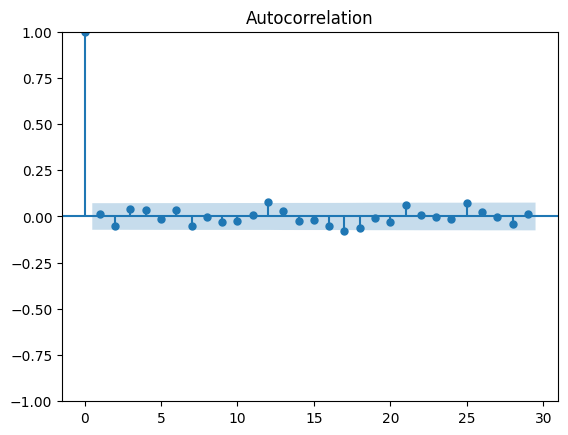

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(fraud_per_hour)
plt.show()

Checking for class imbalance

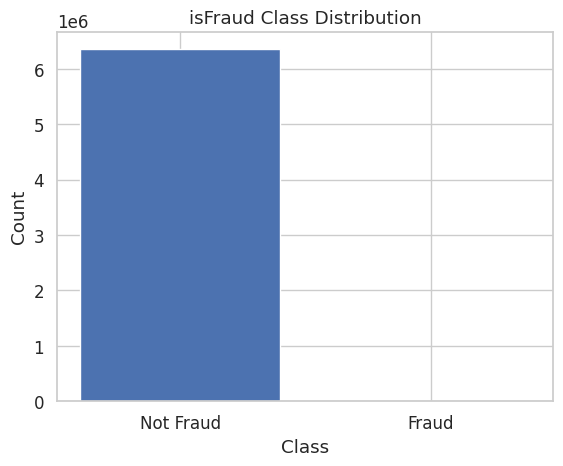

In [ ]:
y = df['isFraud']

count_class = y.value_counts()

plt.bar(count_class.index, count_class.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('isFraud Class Distribution')
plt.xticks(count_class.index, ['Not Fraud', 'Fraud'])
plt.show()


Decision Tree Classifier

In [ ]:
# Encode 'type' column (categorical to numeric)
df['type'] = LabelEncoder().fit_transform(df['type'])

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

dt_model = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy' for information gain
    max_depth=10,      # Limit depth to avoid overfitting
    min_samples_split=50,
    random_state=42
)
dt_model.fit(X_train_res, y_train_res)

y_pred = dt_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("\nROC AUC Score:", roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1]))


Confusion Matrix:
 [[1259523   11358]
 [     13    1630]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.13      0.99      0.22      1643

    accuracy                           0.99   1272524
   macro avg       0.56      0.99      0.61   1272524
weighted avg       1.00      0.99      0.99   1272524


ROC AUC Score: 0.99630220788323


Random Forest Classifier

In [31]:
data_encoded = pd.get_dummies(df, columns=['type'])

In [32]:
X = data_encoded.drop(columns=['isFraud'])
y = data_encoded['isFraud']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9993367512125508
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.67      0.95      0.79      1643

    accuracy                           1.00   1272524
   macro avg       0.84      0.98      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



Naive Bayes Classifier

In [ ]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

nb_model = GaussianNB()
nb_model.fit(X_train_res_scaled, y_train_res)

y_pred = nb_model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("\nROC AUC Score:", roc_auc_score(y_test, nb_model.predict_proba(X_test_scaled)[:, 1]))

Confusion Matrix:
 [[1192682   78199]
 [    699     944]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97   1270881
           1       0.01      0.57      0.02      1643

    accuracy                           0.94   1272524
   macro avg       0.51      0.76      0.50   1272524
weighted avg       1.00      0.94      0.97   1272524


ROC AUC Score: 0.8385483918691525


KNN Classifier

In [ ]:
df['type'] = LabelEncoder().fit_transform(df['type'])

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res_scaled, y_train_res)

y_pred = knn.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("\nROC AUC Score:", roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]))

Confusion Matrix:
 [[1255167   15714]
 [     83    1560]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.09      0.95      0.16      1643

    accuracy                           0.99   1272524
   macro avg       0.55      0.97      0.58   1272524
weighted avg       1.00      0.99      0.99   1272524


ROC AUC Score: 0.9770169744412156
